# v2 — Step 02: Quality Control

## Purpose
Compute per-cell QC metrics, visualise distributions, select empirically justified filtering
thresholds, apply them, and save a clean filtered AnnData.

## QC metrics computed
| Metric | Column | Interpretation |
|--------|--------|----------------|
| Genes detected | `n_genes_by_counts` | Low = empty droplet or dying cell; high = multiplet |
| Total UMIs | `total_counts` | Low = poor capture; high = multiplet |
| MT fraction | `pct_counts_mt` | High = membrane-compromised/dying cell; cytoplasmic mRNA leaks |
| Ribo fraction | `pct_counts_ribo` | Informative; not filtered on directly |

## Input
- `data/processed/v2/GSE116222_v2_raw.h5ad`

## Output
- `data/processed/v2/GSE116222_v2_qc_filtered.h5ad`

In [5]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.set_figure_params(dpi=150, facecolor='white', frameon=False)
os.chdir("/Users/Vicky/vicky/UC_Single_Cell_analysis")
print("cwd:", os.getcwd())
CONDITION_ORDER = ['Healthy', 'UC_noninflamed', 'UC_inflamed']
SAMPLE_ORDER = [
    'A1_healthy', 'A2_non_inflamed', 'A3_inflamed',
    'B1_healthy', 'B2_non_inflamed', 'B3_inflamed',
    'C1_healthy', 'C2_non_inflamed', 'C3_inflamed'
]

cwd: /Users/Vicky/vicky/UC_Single_Cell_analysis


In [6]:
adata = sc.read_h5ad('data/processed/v2/GSE116222_v2_raw.h5ad')
print(f"Loaded: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(adata)

Loaded: 11,175 cells × 58,690 genes
AnnData object with n_obs × n_vars = 11175 × 58690
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    layers: 'counts'


## Compute QC metrics

We recompute QC metrics on the merged dataset so that gene-level statistics
(e.g., `n_cells_by_counts` — how many cells express each gene) reflect the full
11,175-cell dataset rather than individual sample-level counts.

**Mitochondrial genes** (prefix `MT-`) report cytoplasmic RNA leak — high MT% indicates
a broken cell membrane, meaning the cell's cytoplasmic mRNA has escaped while mitochondrial
mRNA (enclosed within the organelle membrane) is retained.

**Ribosomal genes** (`RPS*`, `RPL*`) are highly expressed in all cells and can dominate the
transcriptome. We track them but do not filter on them for colonic epithelial data.

In [7]:
# Annotate gene types
adata.var['mt']   = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

print(f"MT genes   : {adata.var['mt'].sum()}")
print(f"Ribo genes : {adata.var['ribo'].sum()}")

# Calculate metrics (overwrites per-sample values from recovery step)
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt', 'ribo'],
    inplace=True,
    percent_top=None
)
print("\nQC metrics computed. obs columns:")
print([c for c in adata.obs.columns if 'count' in c or 'pct' in c or 'genes' in c])

MT genes   : 37
Ribo genes : 984

QC metrics computed. obs columns:
['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'log1p_total_counts_ribo']


## QC violin plots by condition

Violin plots group cells by condition to reveal whether QC metric distributions
differ between Healthy, UC non-inflamed, and UC inflamed. Genuine biological differences
in cell state can affect MT% (e.g., inflamed cells under stress may have higher MT%).

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/683471536.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


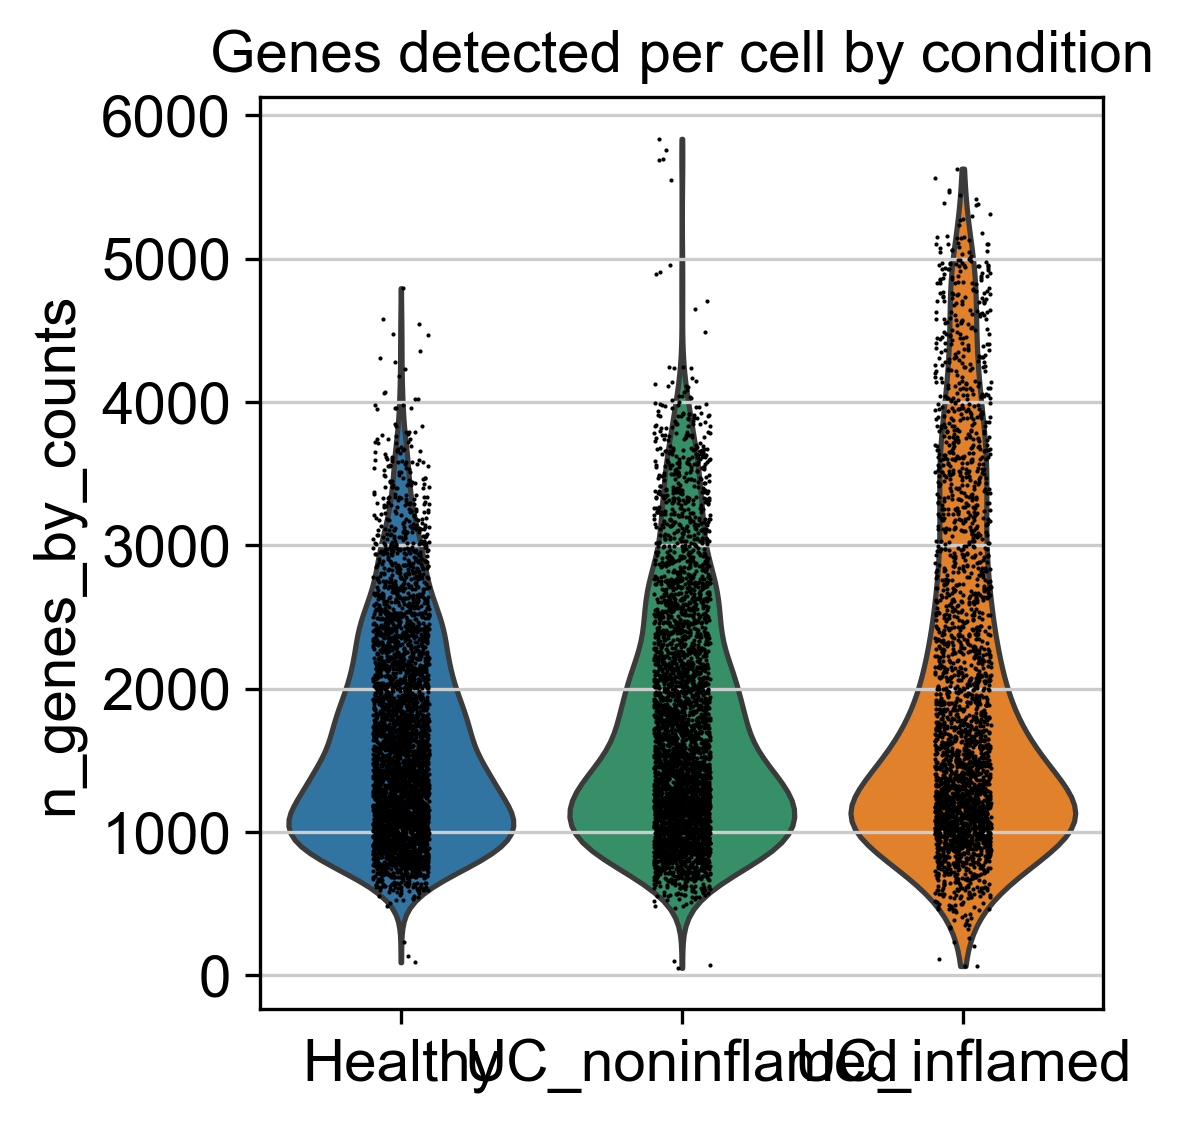

In [8]:
sc.pl.violin(
    adata, 'n_genes_by_counts',
    groupby='condition', order=CONDITION_ORDER,
    rotation=0, show=False
)
plt.title('Genes detected per cell by condition')
plt.tight_layout()
plt.savefig('figures/v2/02_violin_ngenes_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/3050598566.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


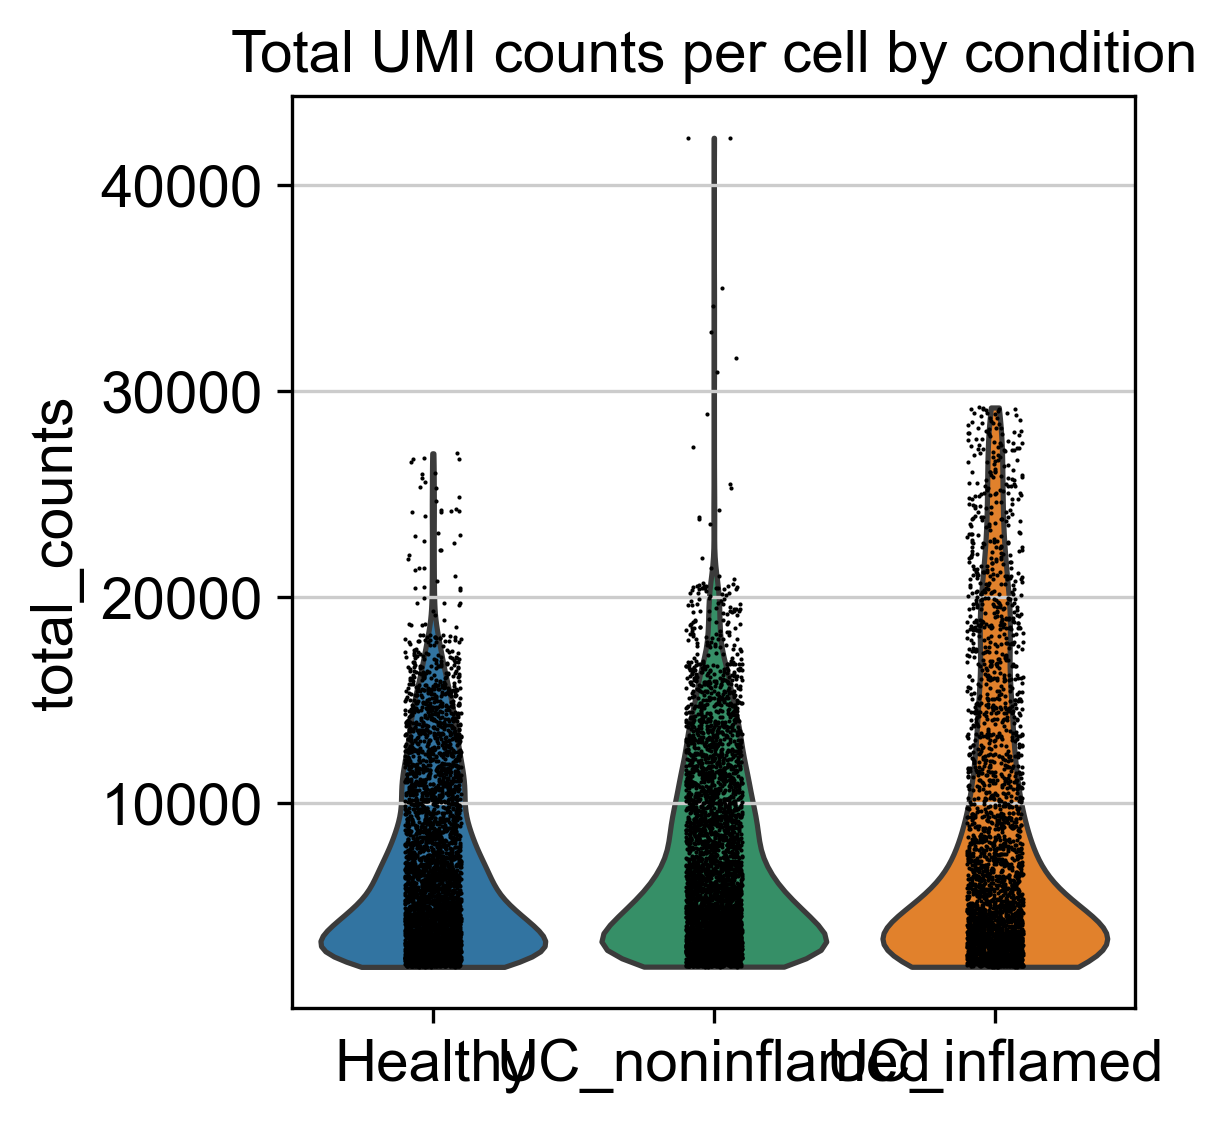

In [9]:
sc.pl.violin(
    adata, 'total_counts',
    groupby='condition', order=CONDITION_ORDER,
    rotation=0, show=False
)
plt.title('Total UMI counts per cell by condition')
plt.tight_layout()
plt.savefig('figures/v2/02_violin_total_counts_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/1800989181.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


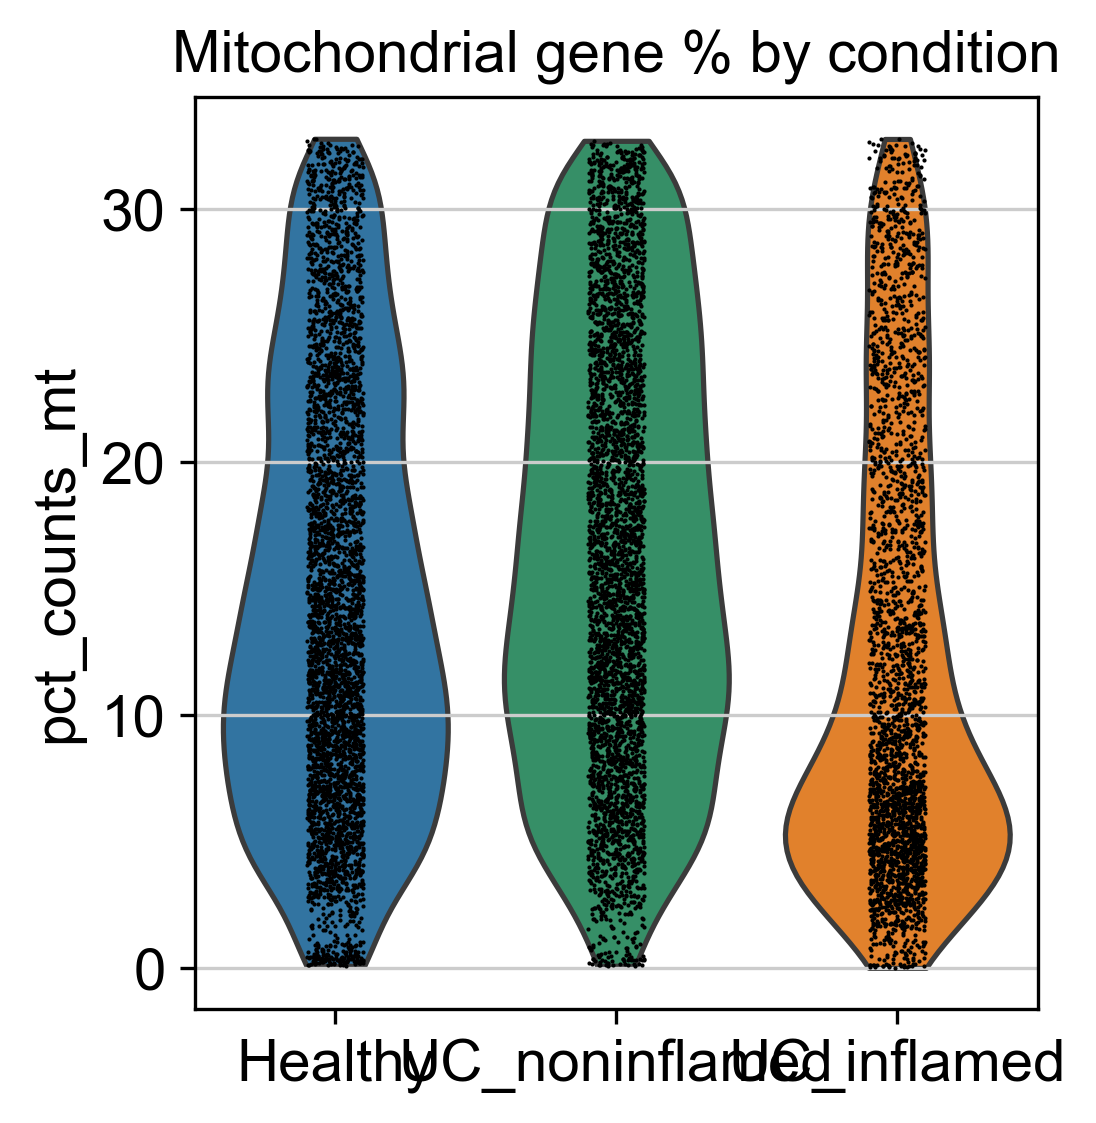

In [10]:
sc.pl.violin(
    adata, 'pct_counts_mt',
    groupby='condition', order=CONDITION_ORDER,
    rotation=0, show=False
)
plt.title('Mitochondrial gene % by condition')
plt.tight_layout()
plt.savefig('figures/v2/02_violin_pct_mt_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/1231264083.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


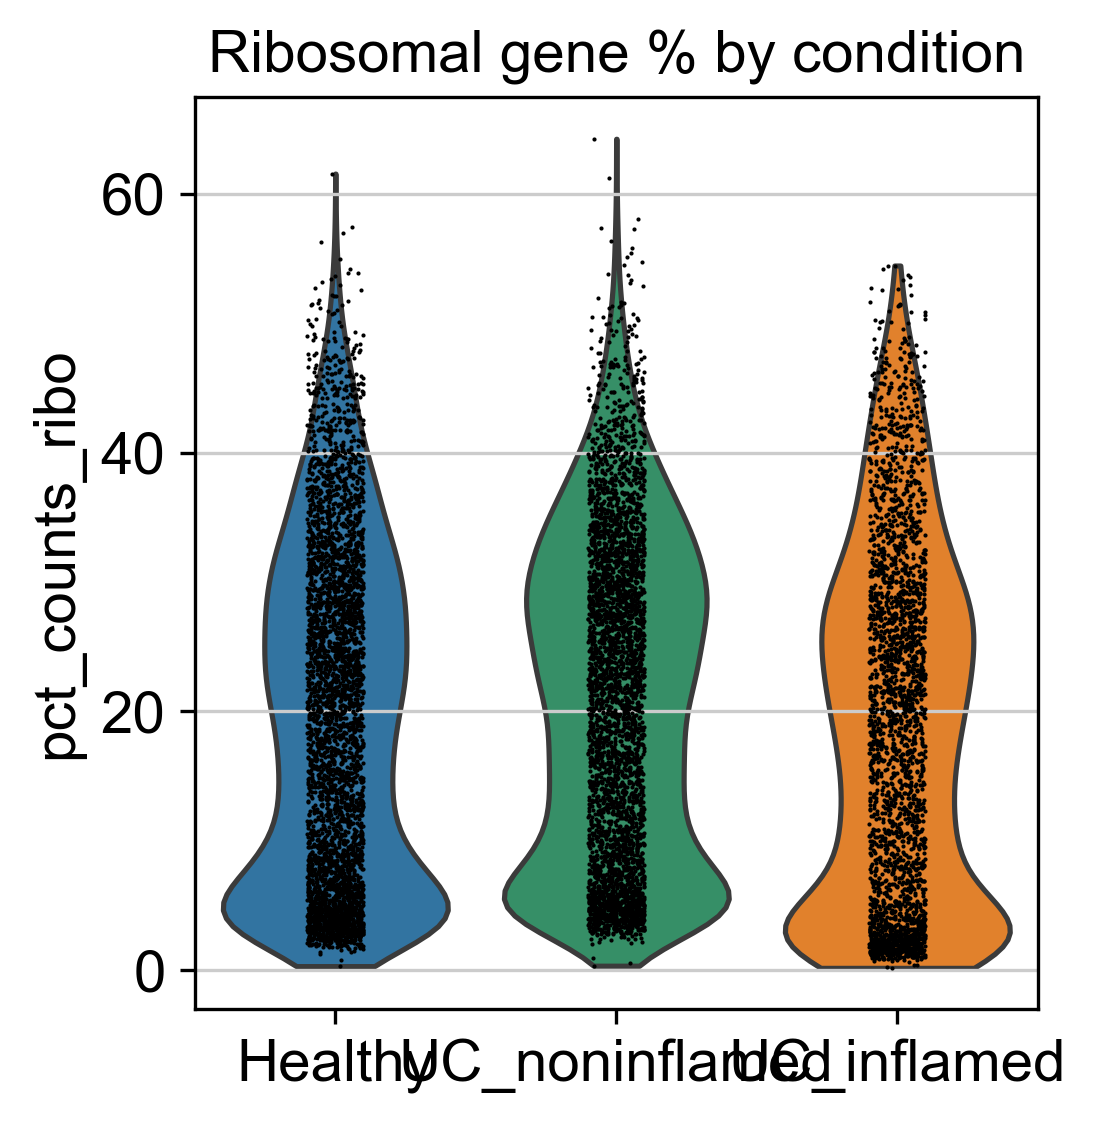

In [11]:
sc.pl.violin(
    adata, 'pct_counts_ribo',
    groupby='condition', order=CONDITION_ORDER,
    rotation=0, show=False
)
plt.title('Ribosomal gene % by condition')
plt.tight_layout()
plt.savefig('figures/v2/02_violin_pct_ribo_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

## QC scatter plots

Scatter plots reveal relationships between QC metrics:
- **Total counts vs genes**: should be roughly linear; outliers above the line may be
  multiplets (two cells in one droplet → inflated counts and gene diversity)
- **Total counts vs MT%**: cells with high MT% and low total counts are classic dying cells

/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/1738960723.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


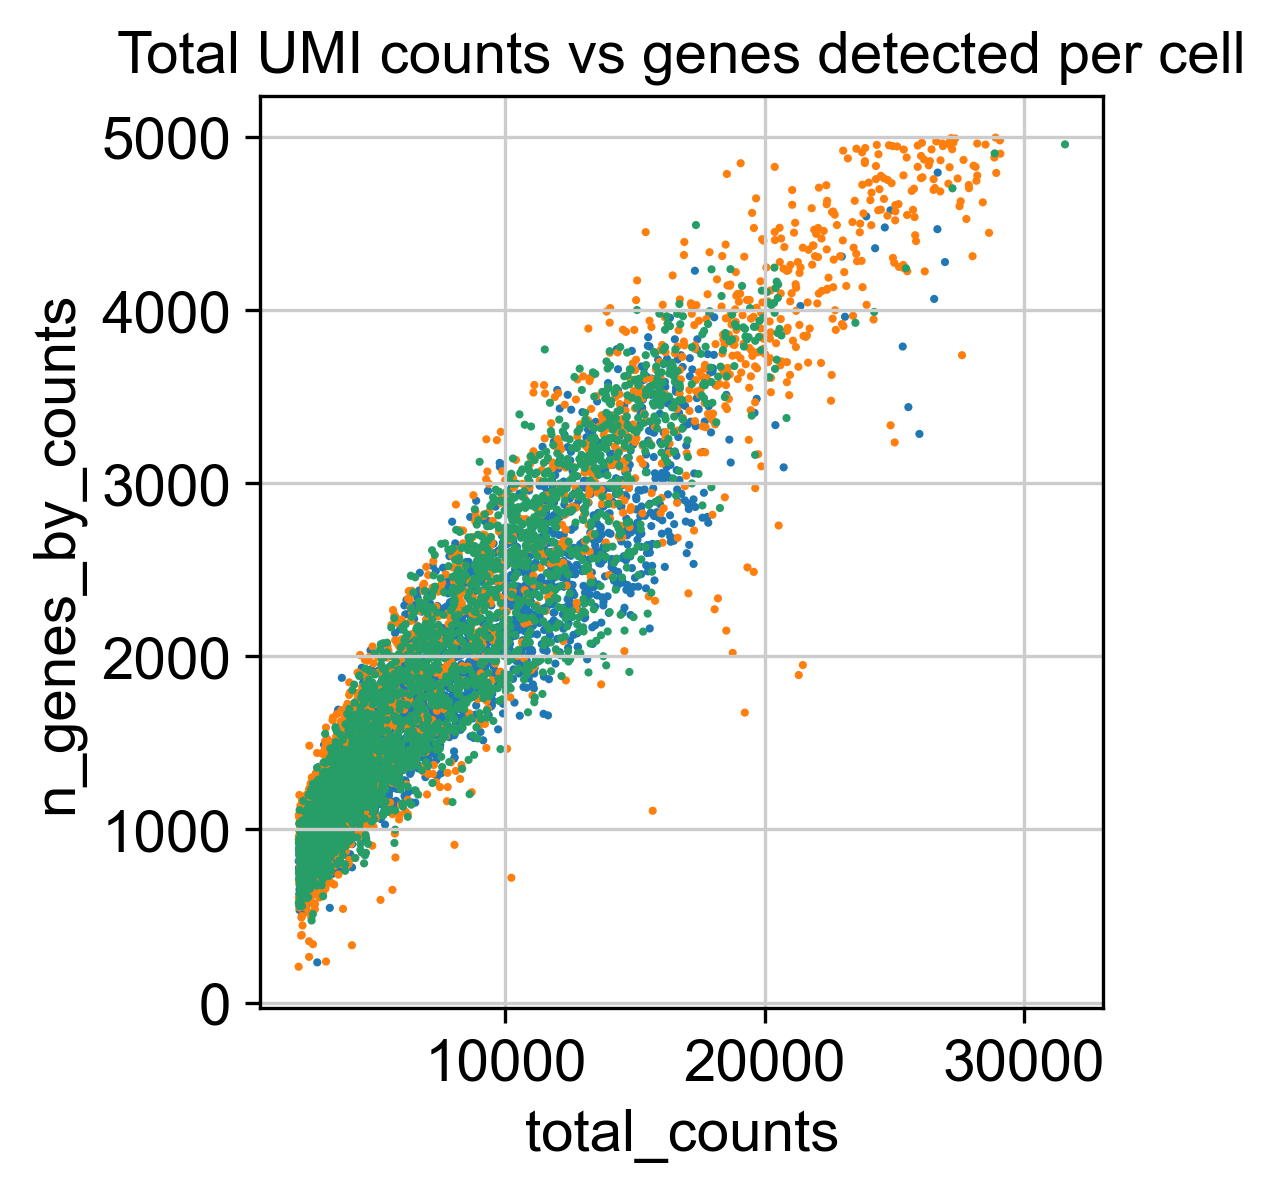

In [24]:
sc.pl.scatter(
    adata, x='total_counts', y='n_genes_by_counts',
    color='condition', legend_loc='none', show=False
)
plt.title('Total UMI counts vs genes detected per cell')
plt.tight_layout()
plt.savefig('figures/v2/02_scatter_counts_vs_genes.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]
/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/336351530.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


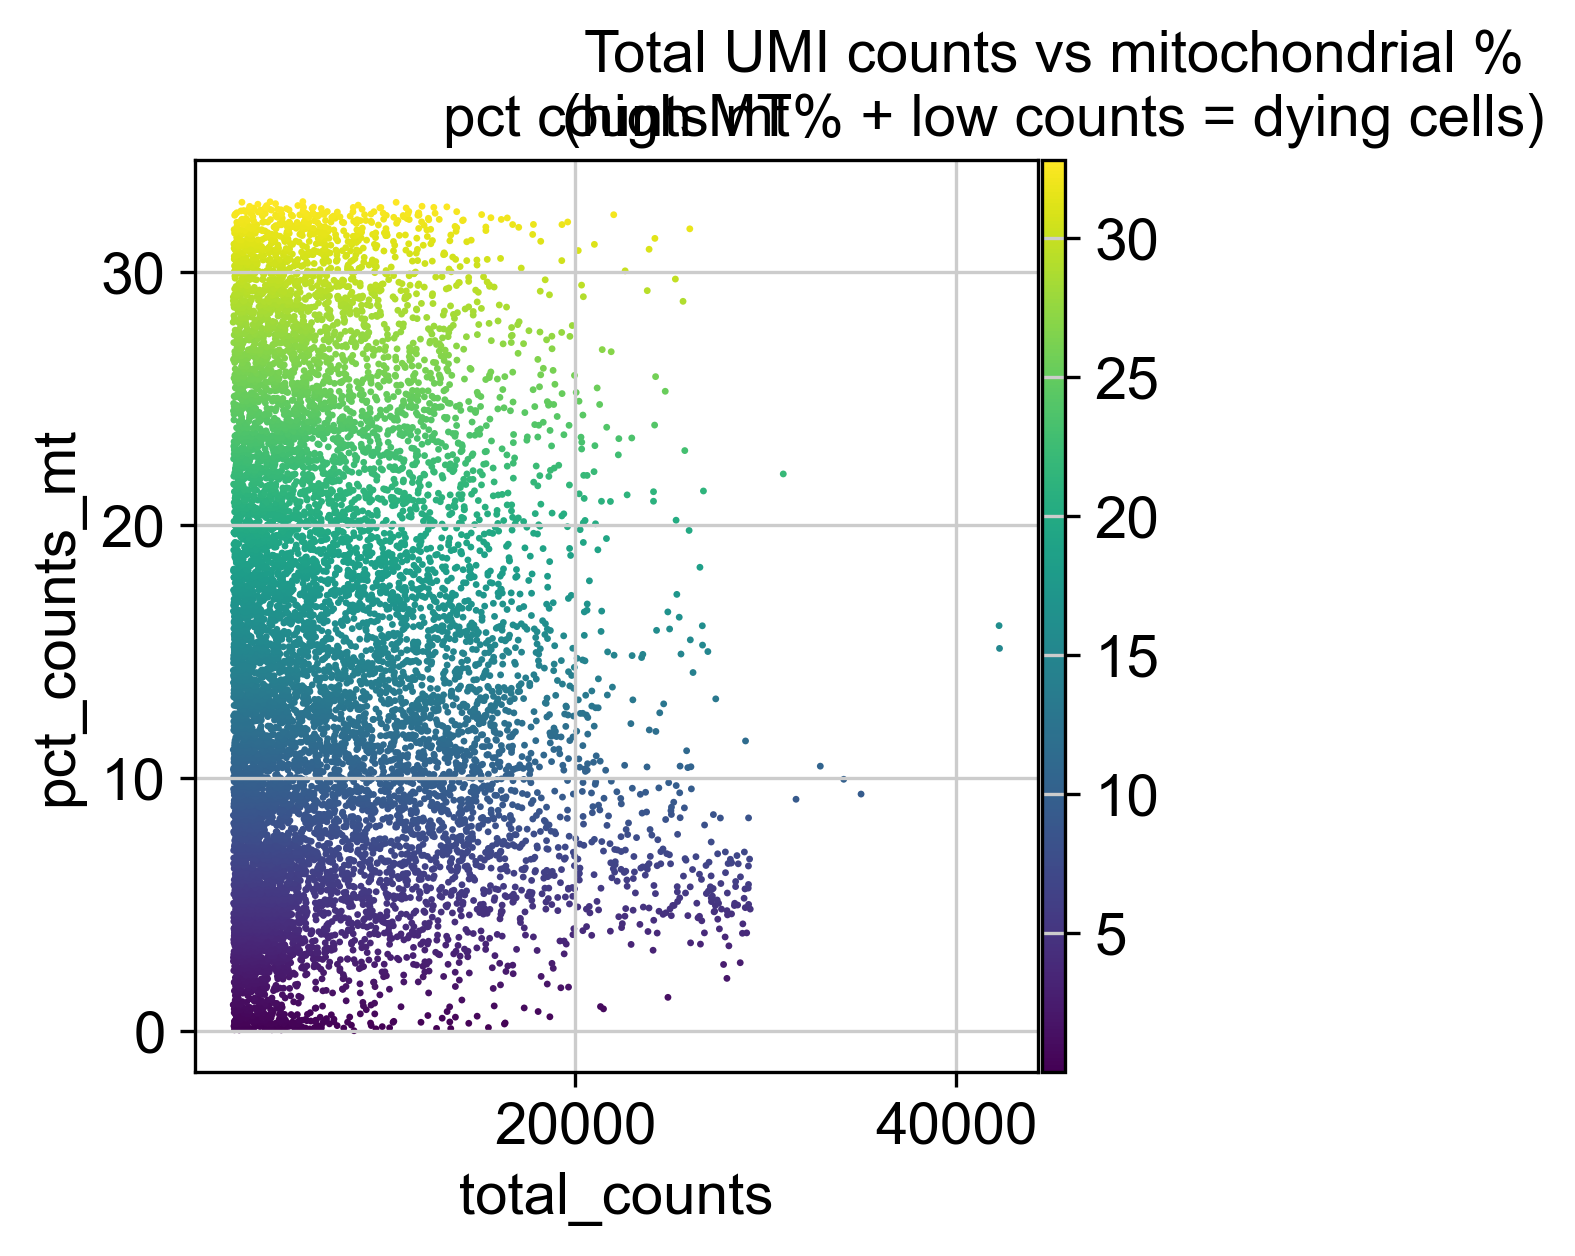

In [13]:
sc.pl.scatter(
    adata, x='total_counts', y='pct_counts_mt',
    color='pct_counts_mt', show=False
)
plt.title('Total UMI counts vs mitochondrial %\n(high MT% + low counts = dying cells)')
plt.tight_layout()
plt.savefig('figures/v2/02_scatter_counts_vs_mt.png', dpi=150, bbox_inches='tight')
plt.show()

## QC distributions per sample

Per-sample violins reveal whether any individual sample is lower quality overall,
which could drive spurious clustering later.

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/2640874630.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


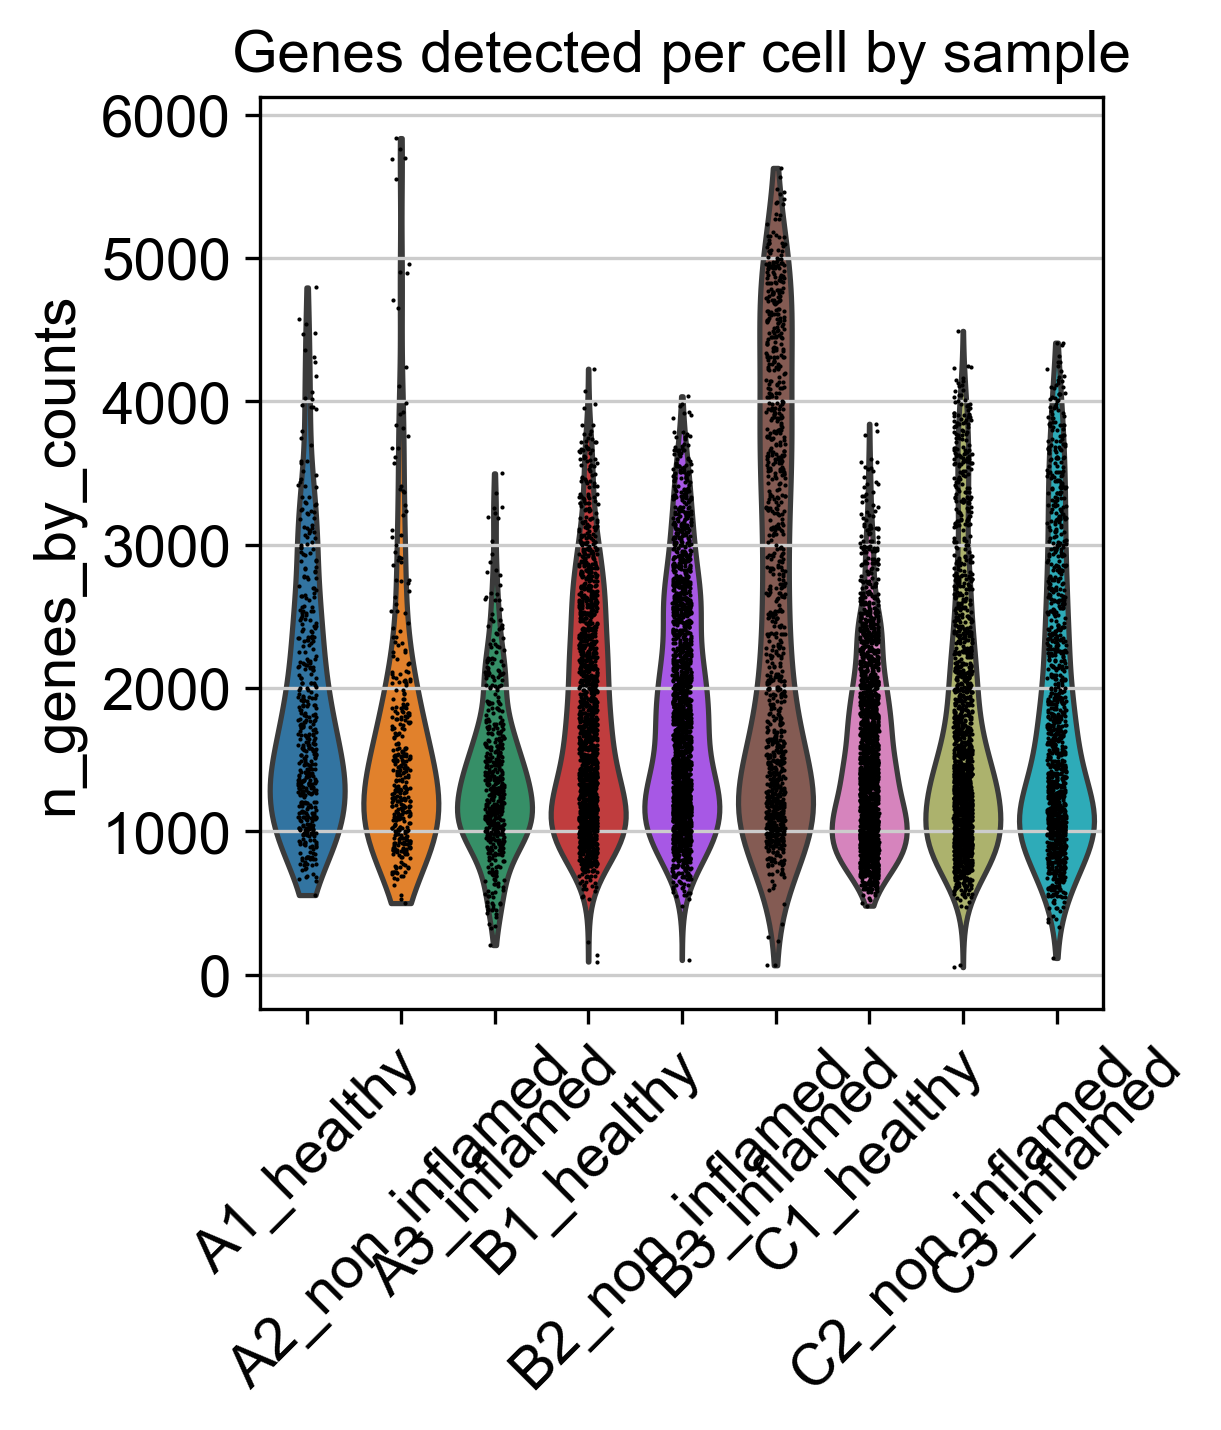

In [14]:
sc.pl.violin(
    adata, 'n_genes_by_counts',
    groupby='sample', order=SAMPLE_ORDER,
    rotation=45, show=False
)
plt.title('Genes detected per cell by sample')
plt.tight_layout()
plt.savefig('figures/v2/02_violin_ngenes_by_sample.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/978313243.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


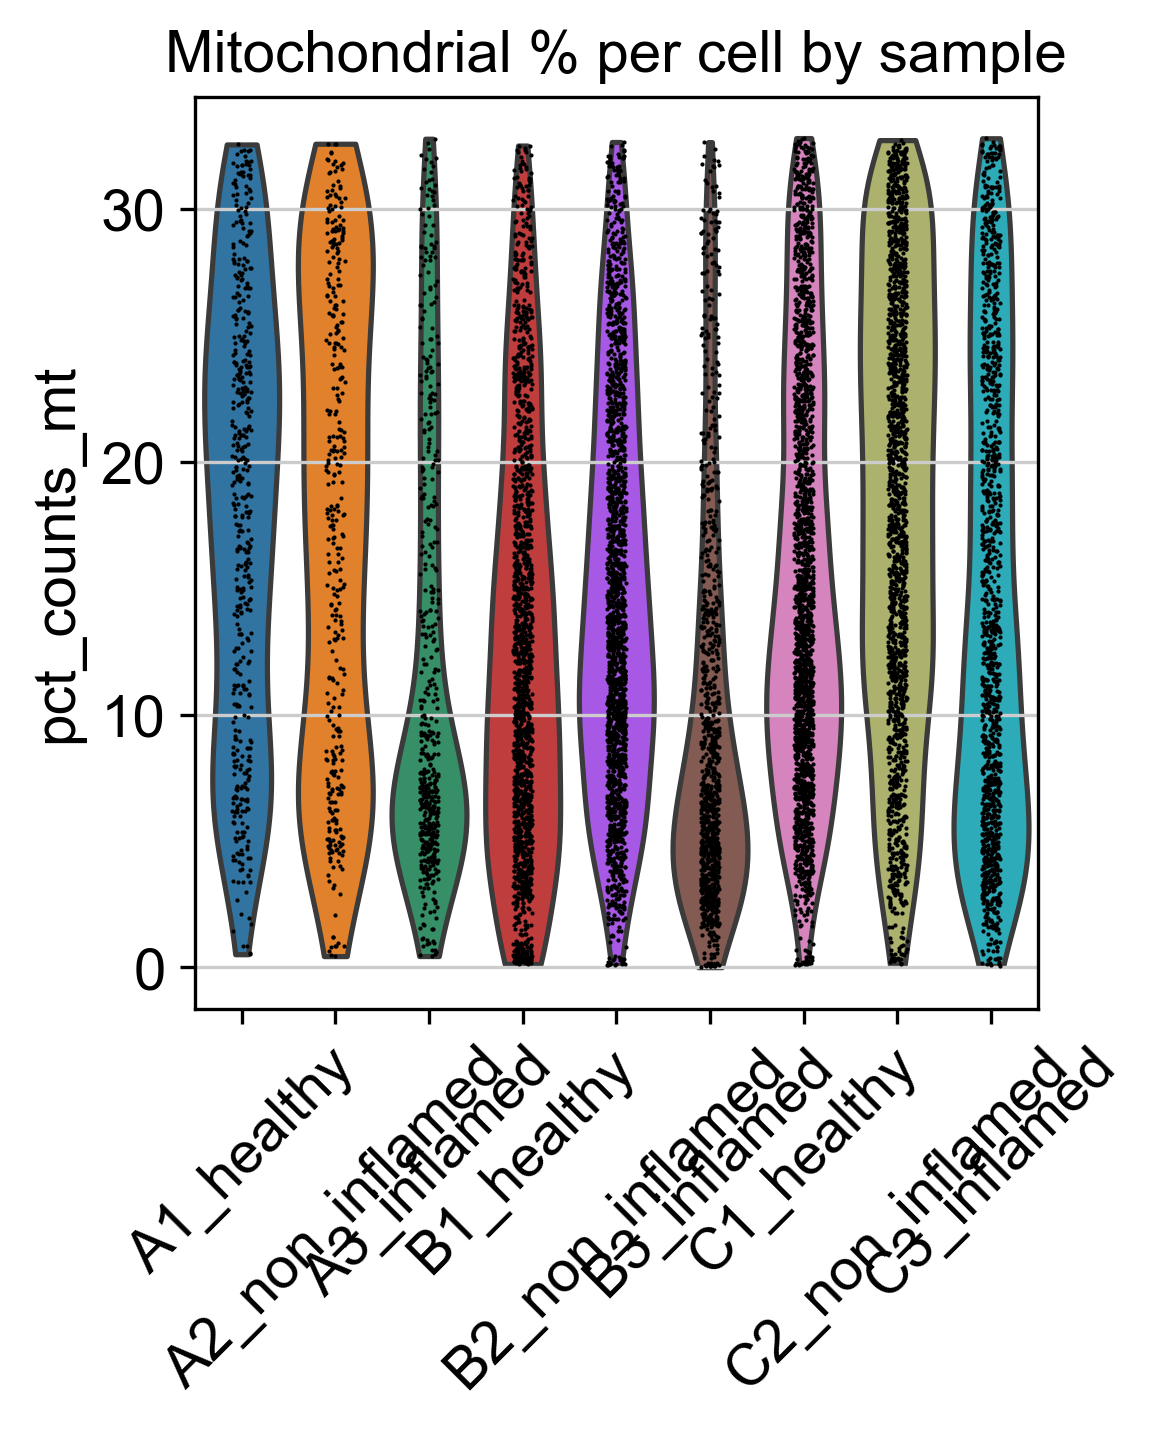

In [15]:
sc.pl.violin(
    adata, 'pct_counts_mt',
    groupby='sample', order=SAMPLE_ORDER,
    rotation=45, show=False
)
plt.title('Mitochondrial % per cell by sample')
plt.tight_layout()
plt.savefig('figures/v2/02_violin_pct_mt_by_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## QC summary statistics per sample

Numeric summary to guide threshold selection — look at median values to set
thresholds that are data-driven rather than arbitrary.

In [16]:
qc_summary = (
    adata.obs
    .groupby('sample')[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo']]
    .agg(['median', 'mean', 'min', 'max'])
    .round(1)
)
# Reorder rows by sample order
qc_summary = qc_summary.loc[SAMPLE_ORDER]
print(qc_summary.to_string())

                n_genes_by_counts                    total_counts                       pct_counts_mt                  pct_counts_ribo                 
                           median    mean  min   max       median     mean   min    max        median  mean  min   max          median  mean  min   max
sample                                                                                                                                                 
A1_healthy                 1588.5  1827.8  556  4795       6414.0   8910.0  2016  26961          18.7  17.9  0.5  32.5            20.1  19.7  2.5  56.9
A2_non_inflamed            1387.5  1646.5  500  5837       4686.0   6932.1  2030  42286          17.9  17.4  0.4  32.6            22.6  21.6  2.8  52.0
A3_inflamed                1294.0  1387.2  207  3498       4153.0   4874.0  2020  13245           7.7  11.8  0.5  32.8            13.1  17.2  0.7  52.6
B1_healthy                 1604.0  1769.6   92  4228       5632.0   7089.3  2037  18138 

/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/3871204604.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sample')[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo']]


## Threshold selection — rationale

Thresholds are chosen based on the observed distributions above, biological knowledge
of the 10x Chromium 3′ v2 platform, and the Parikh et al. (2019) methods:

| Filter | Value | Rationale |
|--------|-------|-----------|
| `n_genes_by_counts` ≥ 200 | min genes | Removes empty droplets |
| `n_genes_by_counts` ≤ 5000 | max genes | Removes likely multiplets; colonic epithelial cells are transcriptionally moderate |
| `pct_counts_mt` ≤ 20% | max MT% | Standard threshold; inflamed epithelial cells can have elevated MT% so we are not too strict |
| min cells per gene ≥ 3 | gene filter | Removes genes detected in fewer than 3 cells; reduces sparsity noise |

In [17]:
MIN_GENES  = 200
MAX_GENES  = 5000
MAX_MT_PCT = 20.0
MIN_CELLS  = 3

print(f"Thresholds applied:")
print(f"  n_genes_by_counts  ≥ {MIN_GENES}")
print(f"  n_genes_by_counts  ≤ {MAX_GENES}")
print(f"  pct_counts_mt      ≤ {MAX_MT_PCT}%")
print(f"  min cells per gene ≥ {MIN_CELLS}")

n_before = adata.n_obs

# Count what each filter removes individually
fail_low_genes  = (adata.obs['n_genes_by_counts'] < MIN_GENES).sum()
fail_high_genes = (adata.obs['n_genes_by_counts'] > MAX_GENES).sum()
fail_mt         = (adata.obs['pct_counts_mt'] > MAX_MT_PCT).sum()

print(f"\nCells failing each filter:")
print(f"  < {MIN_GENES} genes  : {fail_low_genes:4d} cells")
print(f"  > {MAX_GENES} genes  : {fail_high_genes:4d} cells")
print(f"  > {MAX_MT_PCT}% MT  : {fail_mt:4d} cells")

Thresholds applied:
  n_genes_by_counts  ≥ 200
  n_genes_by_counts  ≤ 5000
  pct_counts_mt      ≤ 20.0%
  min cells per gene ≥ 3

Cells failing each filter:
  < 200 genes  :    8 cells
  > 5000 genes  :   41 cells
  > 20.0% MT  : 3336 cells


In [18]:
# Apply cell-level filters
cell_mask = (
    (adata.obs['n_genes_by_counts'] >= MIN_GENES) &
    (adata.obs['n_genes_by_counts'] <= MAX_GENES) &
    (adata.obs['pct_counts_mt'] <= MAX_MT_PCT)
)
adata = adata[cell_mask].copy()
print(f"After cell filter : {adata.n_obs:,} cells  (removed {n_before - adata.n_obs:,})")

n_genes_before = adata.n_vars

# Apply gene-level filter (min 3 cells expressing the gene)
sc.pp.filter_genes(adata, min_cells=MIN_CELLS)
print(f"After gene filter : {adata.n_vars:,} genes (removed {n_genes_before - adata.n_vars:,})")
print(f"\nFinal filtered dataset: {adata.n_obs:,} cells × {adata.n_vars:,} genes")

After cell filter : 7,791 cells  (removed 3,384)
After gene filter : 21,970 genes (removed 36,720)

Final filtered dataset: 7,791 cells × 21,970 genes


## Post-filter QC check

Re-examine distributions after filtering to confirm thresholds were appropriate.

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/4104656905.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


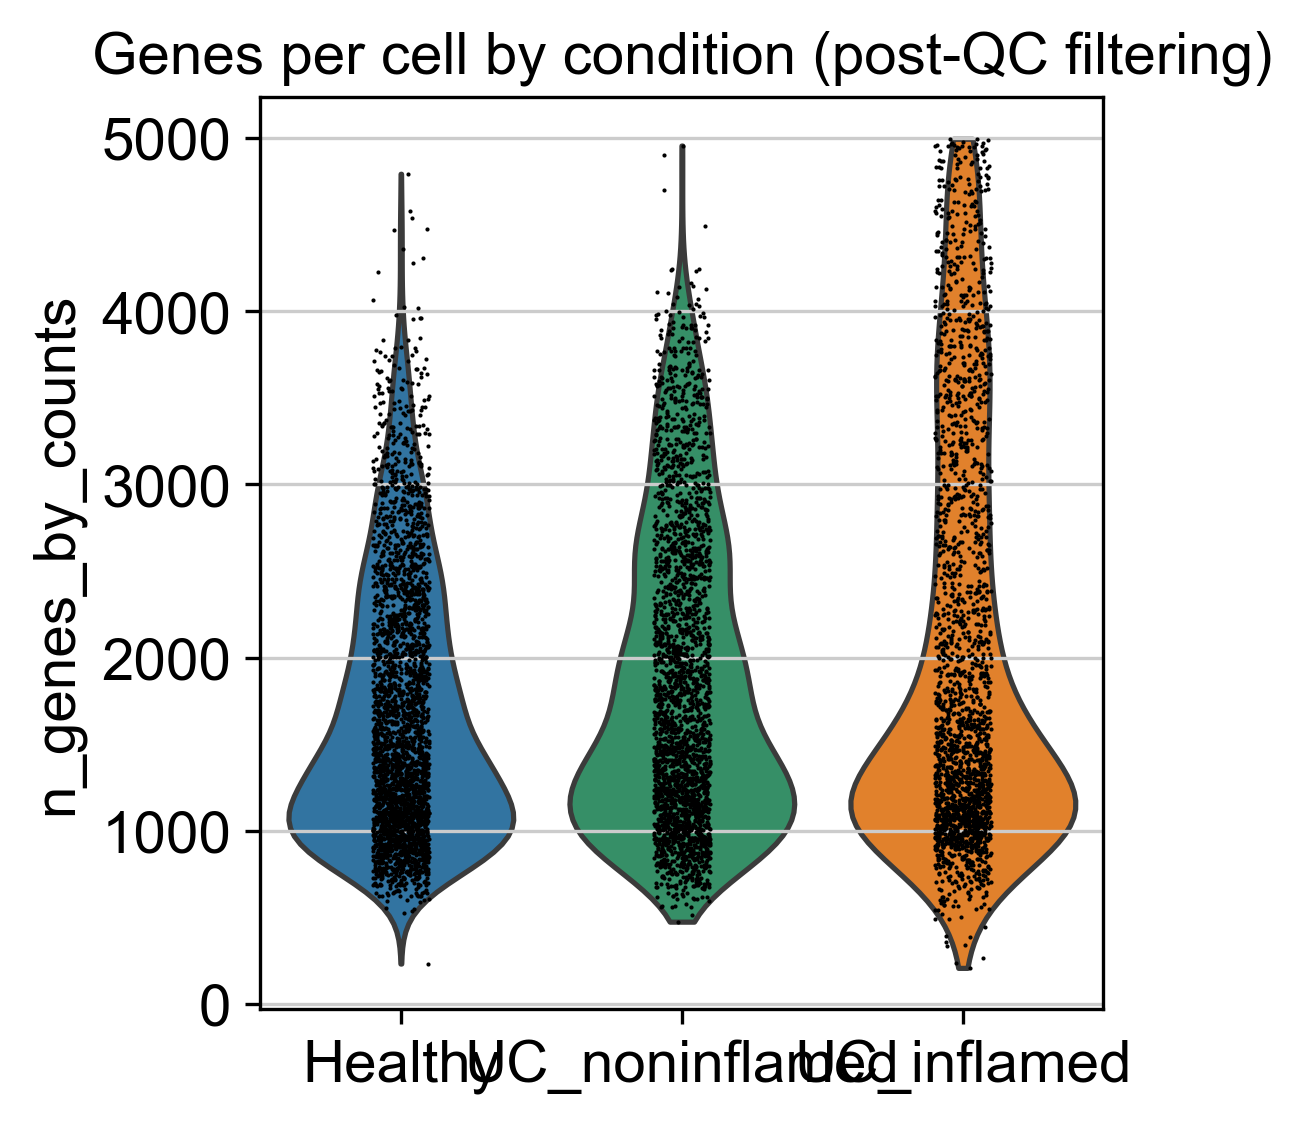

In [19]:
sc.pl.violin(
    adata, 'n_genes_by_counts',
    groupby='condition', order=CONDITION_ORDER,
    rotation=0, show=False
)
plt.title('Genes per cell by condition (post-QC filtering)')
plt.tight_layout()
plt.savefig('figures/v2/02_violin_ngenes_postQC.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/4145510864.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


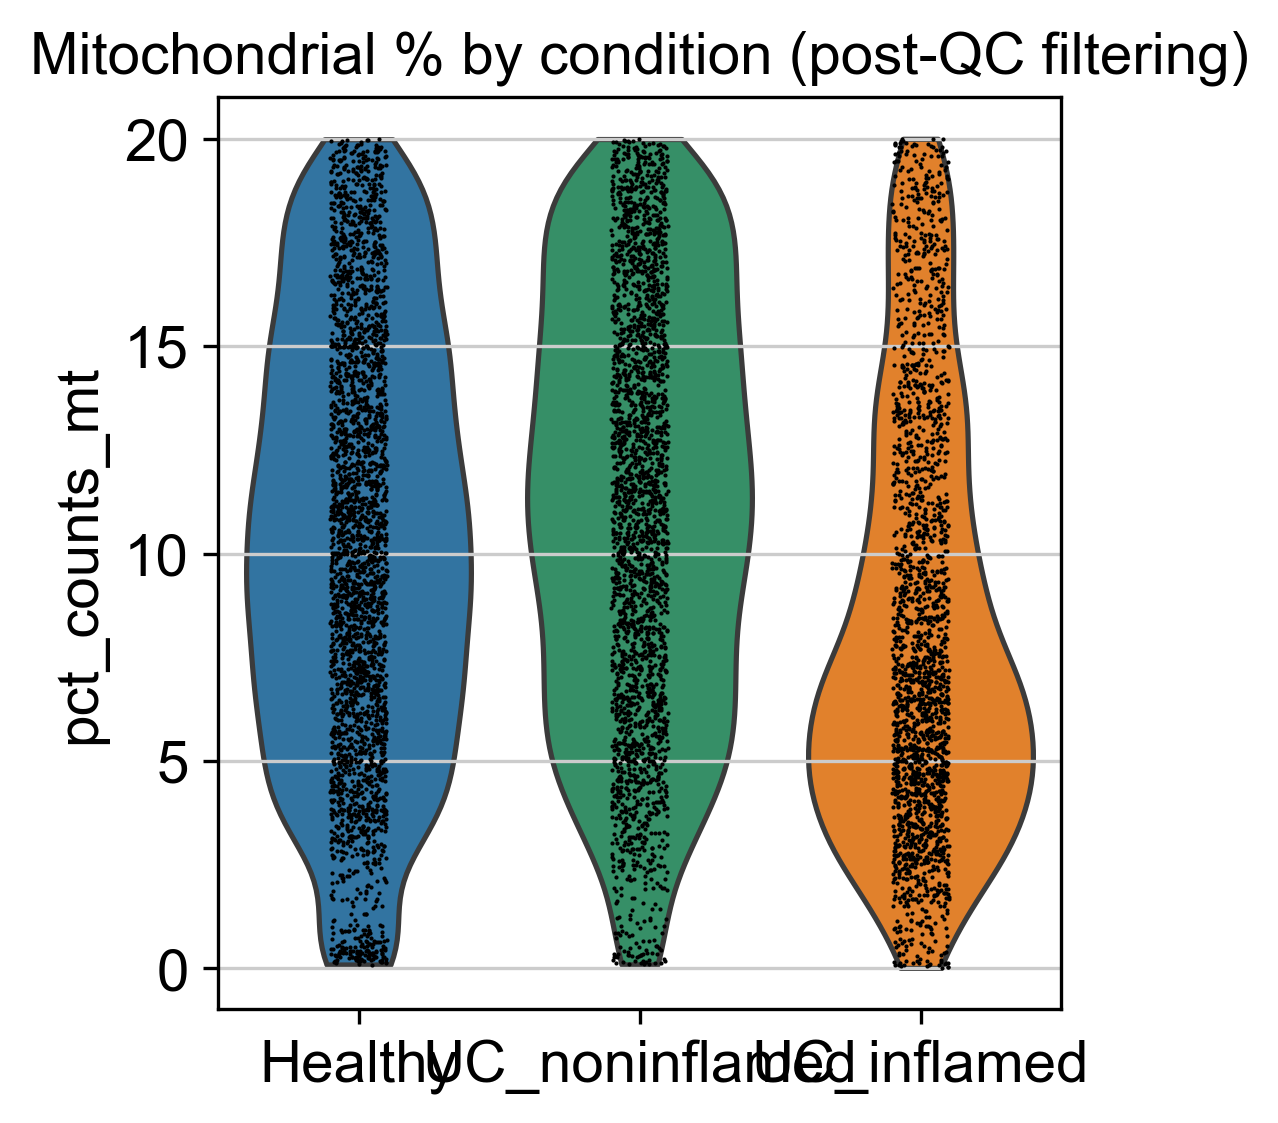

In [20]:
sc.pl.violin(
    adata, 'pct_counts_mt',
    groupby='condition', order=CONDITION_ORDER,
    rotation=0, show=False
)
plt.title('Mitochondrial % by condition (post-QC filtering)')
plt.tight_layout()
plt.savefig('figures/v2/02_violin_pct_mt_postQC.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Post-filter cell counts per sample
print("Cells retained per sample after QC:")
print(adata.obs.groupby(['condition', 'sample']).size().rename('n_cells').to_string())

Cells retained per sample after QC:
condition       sample         
Healthy         A1_healthy          263
                A2_non_inflamed       0
                A3_inflamed           0
                B1_healthy         1271
                B2_non_inflamed       0
                B3_inflamed           0
                C1_healthy         1488
                C2_non_inflamed       0
                C3_inflamed           0
UC_inflamed     A1_healthy            0
                A2_non_inflamed       0
                A3_inflamed         421
                B1_healthy            0
                B2_non_inflamed       0
                B3_inflamed         876
                C1_healthy            0
                C2_non_inflamed       0
                C3_inflamed         876
UC_noninflamed  A1_healthy            0
                A2_non_inflamed     204
                A3_inflamed           0
                B1_healthy            0
                B2_non_inflamed    1453
            

/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_35613/3565987548.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby(['condition', 'sample']).size().rename('n_cells').to_string())


## Save QC-filtered AnnData

In [22]:
out_path = 'data/processed/v2/GSE116222_v2_qc_filtered.h5ad'
adata.write_h5ad(out_path)
print(f"Saved: {out_path}")
print(f"File size: {os.path.getsize(out_path) / 1e6:.1f} MB")
print(f"\nFinal shape: {adata.n_obs:,} cells × {adata.n_vars:,} genes")

Saved: data/processed/v2/GSE116222_v2_qc_filtered.h5ad
File size: 233.0 MB

Final shape: 7,791 cells × 21,970 genes
